In [3]:
import numpy as np

# 1. Base : [tempo_uso (h), volume_transacoes (k) e classe (0: Básico, 1: Premium)]
X_treino = np.array([
    [1.0, 1.0],
    [2.0, 2.0],
    [3.0, 2.0],
    [6.0, 5.0],
    [7.0, 6.0],
    [8.0, 7.0],
])

y_treino = np.array([0, 0, 0, 1, 1, 1])

#2. Novo ponto que queremos classificar
novo_ponto = np.array([6.5, 5.5])

#3. Distâncias euclidianas vetorizadas de uma só vez para todas as linhas
# np.linalg.norm sqrt((x1 - p1)^2 + (x2 - p2)^2) para cada linha
# ord=2 calcula a distancia euclidiana | ord=1 calcula a distancia manhattan
dist_euclidiana = np.linalg.norm(X_treino - novo_ponto, ord=2,  axis=1)
dist_manhattan = np.linalg.norm(X_treino - novo_ponto, ord=1,  axis=1)

#4. Encontra os índices dos K vizinhos mais próximos ( k = 3)
# np.argsort retorna os índices que ordenam o vetor da menor para a maior distância
k = 3
vizinhos_idx = np.argsort(dist_manhattan)[:k]

#5. Votação da maioria ( moda dos rótulos dos vizinhos)
# y_treino[vizinhos_idx] obtém as classes dos 3 vizinhos (ex: [ 1, 1, 0] )
# np.bincount conta a frequência de cada classe
# .argmax() retorna a classe com maior quantidade de votos
votos = y_treino[vizinhos_idx]
classe_predita = int(np.bincount(votos).argmax())

print(f"Distâncias Euclidianas: {np.round(dist_euclidiana, 2)}")
print(f"Distâncias Manhattan: {np.round(dist_manhattan, 2)}")
print(f"Índices dos {k} vizinhos:      {vizinhos_idx}")
print(f"Classes dos vizinhos:         {votos}")
print(f"Classe Predita:               {'Premium (1)' if classe_predita == 1 else 'Básico (0)'}")

Distâncias Euclidianas: [7.11 5.7  4.95 0.71 0.71 2.12]
Distâncias Manhattan: [10.  8.  7.  1.  1.  3.]
Índices dos 3 vizinhos:      [3 4 5]
Classes dos vizinhos:         [1 1 1]
Classe Predita:               Premium (1)


In [4]:
def calcular_distancias(X, ponto, metrica="euclidiana"):
    """ 
    Calcula distâncias vetorizadas para todas as linhas da matrix X.
    Euclidiana ord=2
    Manhattan ord=1
    """

    if metrica == "euclidiana":
        return np.linalg.norm(X - ponto, ord=2, axis=1)
    elif metrica == "manhattan":
        return np.linalg.norm(X - ponto, ord=1, axis=1)
    else:
        raise ValueError("Métrica inválida. Escolha 'euclidiana' ou 'manhattan'.")

def knn_classificar(X, y, ponto, k=3, metrica="euclidiana"):
    """ Classifica um ponto com base na votação dos k vizinhos mais próximos """

    # 1. Calcula distâncias vetorizadas conforme a métrica escolhida
    distancias = calcular_distancias(X, ponto, metrica=metrica)

    # 2. Localiza os k índices mais próximos
    vizinhos = np.argsort(distancias)[:k]

    # 3. Elege a classe majoritártia (moda)
    classe_vencedora = int(np.bincount(y[vizinhos]).argmax())

    return classe_vencedora, vizinhos, distancias[vizinhos]

def knn_recomendar(X, ponto_referencia, k=3, metrica="euclidiana"):
    """ Retorna os índices e distâncias dos k itens mais semelhantes no catálogo."""

    # 1. Calcula distâncias vetorizadas conforme a métrica escolhida
    distancias = calcular_distancias(X, ponto_referencia, metrica=metrica)

    # 2. Retorna os k itens mais próximos (menor distância)
    vizinhos = np.argsort(distancias)[:k]

    return vizinhos, distancias[vizinhos]

In [5]:
# Teste de classificação
ponto_teste = np.array([2.5, 2.0])

for metrica in ["euclidiana", "manhattan"]:
    classe, vizinhos, dists = knn_classificar(
        X_treino, y_treino, ponto_teste, k=3, metrica=metrica
    )
    rotulo = "Premium" if classe == 1 else "Básico"

    print(f"--- Métrica: Distância {metrica.capitalize()} (K=3) ---")
    print(f"Ponto {ponto_teste} -> Classificado como: {rotulo}")
    print(f"Vizinhos consultados: índices {vizinhos} com distâncias {np.round(dists, 2)}\n")

--- Métrica: Distância Euclidiana (K=3) ---
Ponto [2.5 2. ] -> Classificado como: Básico
Vizinhos consultados: índices [1 2 0] com distâncias [0.5 0.5 1.8]

--- Métrica: Distância Manhattan (K=3) ---
Ponto [2.5 2. ] -> Classificado como: Básico
Vizinhos consultados: índices [1 2 0] com distâncias [0.5 0.5 2.5]



In [7]:
# Recomendação por Similaridade
item_referencia = np.array([7.0, 6.5])

for metrica in ["euclidiana", "manhattan"]:
    indices_rec, distancias_rec = knn_recomendar(
        X_treino, item_referencia, k=4, metrica=metrica
    )

    print(f"Top 2 Itens mais parecidos ({metrica.capitalize()}):")
    for pos, (idx, d) in enumerate(zip(indices_rec, distancias_rec), start=1):
        print(f" {pos}º Lugar: Item #{idx} (Atributos: {X_treino[idx]}) - Distâncias: {d:.2f}")
    print()

Top 2 Itens mais parecidos (Euclidiana):
 1º Lugar: Item #4 (Atributos: [7. 6.]) - Distâncias: 0.50
 2º Lugar: Item #5 (Atributos: [8. 7.]) - Distâncias: 1.12
 3º Lugar: Item #3 (Atributos: [6. 5.]) - Distâncias: 1.80
 4º Lugar: Item #2 (Atributos: [3. 2.]) - Distâncias: 6.02

Top 2 Itens mais parecidos (Manhattan):
 1º Lugar: Item #4 (Atributos: [7. 6.]) - Distâncias: 0.50
 2º Lugar: Item #5 (Atributos: [8. 7.]) - Distâncias: 1.50
 3º Lugar: Item #3 (Atributos: [6. 5.]) - Distâncias: 2.50
 4º Lugar: Item #2 (Atributos: [3. 2.]) - Distâncias: 8.50



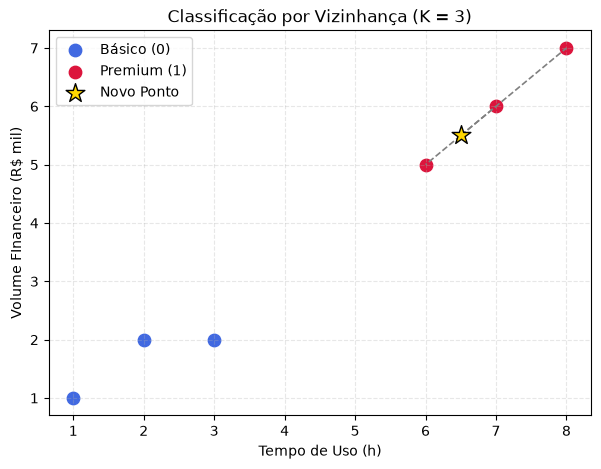

In [9]:
import matplotlib.pyplot as plt

# 1. Plot das amostras históricas
plt.figure(figsize=(7, 5))
plt.scatter(X_treino[y_treino == 0, 0], X_treino[y_treino == 0, 1], color="royalblue", 
            s=80, label="Básico (0)")
plt.scatter(X_treino[y_treino == 1, 0], X_treino[y_treino == 1, 1], color="crimson", 
            s=80, label="Premium (1)")

# 2. Plot do novo ponto
plt.scatter(novo_ponto[0], novo_ponto[1], 
            color="gold", marker="*", s=200, edgecolors="black", label="Novo Ponto", zorder=5)

# 3. Linhas conectando o ponto aos 3 vizinhos mais proximos
for idx in vizinhos_idx:
    plt.plot([novo_ponto[0], X_treino[idx, 0]], [novo_ponto[1], X_treino[idx, 1]], 
             color="gray", linestyle="--", linewidth=1.2)

plt.title("Classificação por Vizinhança (K = 3)")
plt.xlabel("Tempo de Uso (h)")
plt.ylabel("Volume FInanceiro (R$ mil)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()